Just an Infinite Potential Square well    

- Need to correct code and make it compatible for custom potentials
- GPU Acceleration
- 

- Hand
- U/I interface

Rigorous BC enforcement
⬜ Orthonormality diagnostic plots
⬜ Convergence analysis
⬜ Analytic solution benchmarking
⬜ Documentation + modular design

- - First Principle thinking on what V(x) means:
V(x) describes the landscape of potential created by the environment. Kind of like a Map of the region, maybe even think of it as a hill contour. 

- - If V(x) = 2 . Then if we place a particle there, the particle would experience a force proportional to V(x) = 2. Meaning! it needs to release/ Have energy of 2 to move anywhere. or oppose it. Think more like E = K + V. If V is 2 ,we need a kitetic energy proportial to 2. 

- - - Think of V(x) = 2 as a hill with a incline of 2. V(x) = 0 as a solve of inclide as 0, ie a flat surface. Its obvious that its easier to walk on a flat surface than a inclide. Ie, the particle is easeir to move at V(x) = 0 than V(x) = 2. 

Hence, if V(x) = infinity. The particel would need infinite energy to move and overcome. a slove of inifnite. 

We suppose there is an electron of mass (m) 
trapped in an infinite square well of 0 < x < a 
- Where if were inside the well, 0 < x < a: the Potential V(x) = 0
- If were outside, Potential V(x) = infinity. 


### The Shroudinger Time Independent eqation: 
$H \Psi = E\Psi $ is the $ - \frac{\hbar^2}{2m} \frac{d^2}{dx^2} \Psi = E \Psi$ (TISE)




We enforce some conditions on this wave, based on what we observe about waves. 
- $\Psi(0) = \Psi(a) = 0$ (Drachet Conditions) 
- - Why this is because, Schrodinger Demans $\Psi(x)$ should be continous, becase if it wasn't, its Second derevative would go to infinty which would mean the Kinetic energy would go to inifnity. So we need the Boundary to be continous. Ie $ \Psi(0^+) = \Psi(0^-)$ But we know that $\Psi(0^-) = 0 $ Hence $\Psi(0^+) = 0$ , Simply $\Psi(0) = 0$

- $ \int_\inf^b {{\Psi(x)}^2 }  $

- $ \abs( \Psi(x) )^2 * dx $ (The probability density times an infitiesmal dx ) , the probability that the particle is found between x and x + dx. 






The known solutions:

$\Psi_{}{n} (x) = \sqrt{\frac{2}{a}} \sin(\frac{n \pi x}{a})$
and Energy levels are $E_{}{n} = \frac{\hbar^2 \pi^2 n^2}{2 m a}$

Lets now Convert all this into a Discreate matrix version so that a computer can do this numerically.

We break up the Contnous space into small chunks, 

Specifically we create N chunks of width $\Delta x$
Let them match our sqare well, at x E [0,a]

Look Close at the TISE
$H \Psi = E\Psi $ is the $ - \frac{\hbar^2}{2m} \frac{d^2}{dx^2} \Psi = E \Psi$ (TISE)

we have a continous operator $\frac{d^2}{dx^2}$ that we need to discretize



Now the usual Defination for a derevative is :
$$f'(x_i) = \lim_{\Delta x \to 0} \frac{f(x_i + \Delta x) - f(x_i)}{\Delta x}$$

This is the derevation evlauated at $\Delta x goes to \to 0$;
But in our program we dont want this to go to zero, we want it to be discreate, constant $\Delta x$ which is just the width of our grid spacing. We want this, so that we can evealuate the derevative at discrete points in space rather than find the infetesamal points in space. 

Hence, we just remove the $\lim$ fucntion that makes the $\Delta x \to 0$ and for us convinently, $x_i + \Delta x$ would just be the next slot $x_{i+1}$

Making these adjustments and simplifications, Now we have a the first derevative operator that is compatiable with our grid.
$$ f'(x_i) = \frac{f(x_{i+1} ) - f(x_i)}{\Delta x} $$

This machine has a cool name, the **Forward Difference**. And it literally what it says, it finds the slope between the next point and the current point. There are other types, the backward or the central difference but we will stick to that.  

But remember we need to go further and get the Second derivative, $f''(x_i)$

Because $\Delta x$ is just a constant, we know that derevative of a sum is jsut the sum of the derevatives. so we can roughly say

$$ f''(x_i) \approx \frac{f'(x_{i+1} ) - f'(x_i)}{\Delta x} $$

Notice how the f'(x_i) forward difference formula can be substauted into this, so

$$f''(x_i) \approx \frac{\frac{f(x_{i+1}) - f(x_i)}{\Delta x} - \frac{f(x_i) - f(x_{i-1})}{\Delta x}}{\Delta x} = \frac{f(x_{i+1}) - 2f(x_i) + f(x_{i-1})}{\Delta x^2}
$$


Great, now we have a function that works like the $\frac{d^2}{dx^2}$ and is compatible for our discrete space.

But for a computers work on vectors, and matricies. So we need to convert this to a Matrix Operator. 




For a set of grid points $x_1, x_2, x_3, x_4, \dots$, we can write:
$$
\begin{cases}
f''_1 = \frac{f_2 - 2f_1 + f_0}{(\Delta x)^2}, \\
f''_2 = \frac{f_3 - 2f_2 + f_1}{(\Delta x)^2}, \\
f''_3 = \frac{f_4 - 2f_3 + f_2}{(\Delta x)^2}, \\
\vdots
\end{cases}
$$


Note the Pattern here, there is a [1 , -2 , 1] matters that sweeps the number line. 


$$ f''(x_i)  = \frac{f(x_{i+1}) - 2f(x_i) + f(x_{i-1})}{\Delta x^2}
$$

from this function lets pull out a vector $f(x_i) = \begin{bmatrix}
f_1 \\
f_2 \\
f_3 \\
f_4 \\
\vdots
\end{bmatrix}
$

We could write this operation as :
$$
\frac{d^2}{dx^2} \approx f''(x_i) = \frac{1}{(\Delta x)^2} \begin{bmatrix}
-2 & 1 & 0 & 0 & \cdots \\
1 & -2 & 1 & 0 & \cdots \\
0 & 1 & -2 & 1 & \cdots \\
0 & 0 & 1 & -2 & \cdots \\
\vdots & \vdots & \vdots & \vdots & \ddots
\end{bmatrix} f(x_i)
$$



So our Schroudinger equation 
$$ - \frac{\hbar^2}{2m} * (\mathbf{\frac{d^2}{dx^2}}) \Psi = E \Psi $$
(TISE)

Becomes

$$ - \frac{\hbar^2}{2m} * \mathbf{\frac{1}{(\Delta x)^2} \begin{bmatrix}
-2 & 1 & 0 & 0 & \cdots \\
1 & -2 & 1 & 0 & \cdots \\
0 & 1 & -2 & 1 & \cdots \\
0 & 0 & 1 & -2 & \cdots \\
\vdots & \vdots & \vdots & \vdots & \ddots
\end{bmatrix}} \Psi = E \Psi $$


Note that this matrix would actually only be from $\Psi_1 \to \Psi_{N-1}$ 
Because we dont want the Computer to find $\Psi_0$ and $\Psi_N$, we want to enforce our boundary condition $\Psi_0 = \Psi_N = 0$

Just like how we do this analytically, we are going to tell the computer to find the Eigen Values and Eigen Vectors for this system. 

In [1]:
# Code Begins

import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Grid Parameters

"Limitation: only 0 to L now, not -a to a"
L = 5

N = 2000
x = np.linspace(0,L,N+1) # N+1, because if you need N intervals we need N+1 end points |..|..|
# x0 , x1 ... xN (Thats N+1 end Points)
dx = x[1] - x[0] # a Constant Width


# Constants in AMU
hbar = 1
m = 1

In [3]:
# Define Potential

# Potential Play Grounds

walls_array = []

def constant(c):
    V = c
    return V


def custom(x): 
    ""

def inf_sqaure_well(x,lower_bound,upper_bound):
    "Gives you an Infinite square well of Length L"
    "Takes the Grind Points array x and creates an array of Zeros in the same shape"
    ""
    walls_array.append(lower_bound)
    walls_array.append(upper_bound)

    V = np.zeros_like(x) 
    V[x<lower_bound] = np.inf # Potnetial of infinite below Lower Bound
    V[x>upper_bound] = np.inf # Potnetial of infinte above upper Bound
    # Effetively, all untouced grind points have potential Zero

    return V

def inf_wall(x,side,bound):
    walls_array.append(bound)

    side.strip(', . ').lower
    V = np.zeros_like(x)
    if side =='left':
        V[x<bound] = np.inf
    elif side =='right':
        V[x>bound] = np.inf

    return V

def harmonic(x,center=0,k=1):
    V = np.zeros_like(x)
    constant = 1 #m*L**2
    potential = 0.5*k*(x - center)**2 # Parabola
    return constant*potential

def V_double_well(x, depth=20, separation=1):
    V = depth * ( (x-L/2)**2 - separation )**2
    return V

def custom2(x):
    V = np.zeros_like(x)
    return 2



#V= inf_sqaure_well(x,0,L)

#V = inf_wall(x,'left',bound=0)+harmonic(x)

V = V_double_well(x)

#V = custom2(x)

In [4]:
def wall_plot(array):
    for i in range(len(array)):        
        try: 
            plt.axvline(array[i], color='white', lw=2)
            return
        except NameError:
            None

In [5]:
print(V)

[551.25       548.62943438 546.01772501 ... 546.01772501 548.62943438
 551.25      ]


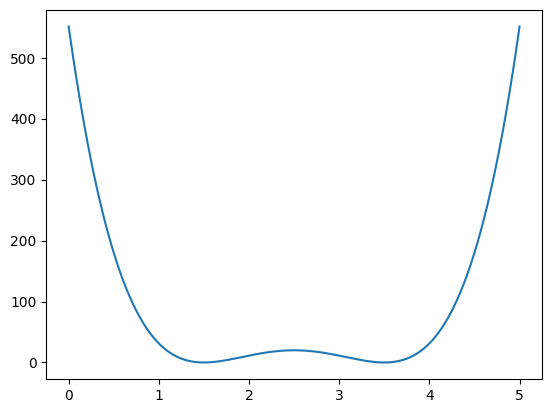

In [6]:
# Debug 
plt.plot(x,V)
wall_plot(walls_array)

In [7]:
# The Differntial operator

main_diagonal = (1/dx**2)*np.diag(-2*np.ones(N-1))
off_diagonal1 = (1/dx**2)*np.diag(np.ones(N-2),-1)
off_diagonal2 = (1/dx**2)*np.diag(np.ones(N-2),1)
D2 =  (main_diagonal + off_diagonal1 + off_diagonal2)
# Becase 2 conditions are given, we need the computer to fill in 
# N+1 - 2 =  thats N-1 end points. The main diagonal would have N-1 points
# the Off diagonal would have N-2 points off diagonal points

"""
print(M)
print(M.shape)
"""

'\nprint(M)\nprint(M.shape)\n'

For NxN = 4x4 matrix
$$ {\begin{bmatrix}
1 & 1 & 0 & 0  \\
1 & 2 & 2 & 0  \\
0 & 2 & 3 & 3  \\
0 & 0 & 3 & 4  \\
\end{bmatrix}} $$

As we can see, Main diagonal of N Elements
Off Diagonlas has N-1 Elements

So our Schroudinger equation 
$$ - \frac{\hbar^2}{2m} * (\mathbf{\frac{d^2}{dx^2}}) \Psi = E \Psi $$
(TISE)

Becomes

In [8]:
# Hamiltonian
T = (-(hbar**2/2*m ) * D2 ) # Recall D is the Differntial Operator 

H = T + np.diag(V[1:-1])

In [9]:
# Solve the Eigen Value Equation

E, psi = np.linalg.eigh(H)  # E is Eigen Value and Psi is Eigen Vector

#psi = psi.T # So we can acess the values by psi[i] ???

$$\int_{x_1}^{x_N} f(x)dx \approx \sum_{i=1}^{N} f(x_i)\Delta x
$$

In [10]:
# Need to Normalize ???
# We Normalize by making the untegral to go to 1. But we need to make the this again compatible to 
# do in a computer

def integral(f, axis=0):
    return np.sum(f*dx,axis=axis)

norm = integral(psi**2)
psi = psi/np.sqrt(norm)

<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:7: SyntaxWarning: invalid escape sequence '\p'
C:\Users\ahila\AppData\Local\Temp\ipykernel_40352\1073578582.py:7: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(x[1:-1], psi[:,n]**2, label = "$\psi_{}$".format(n))


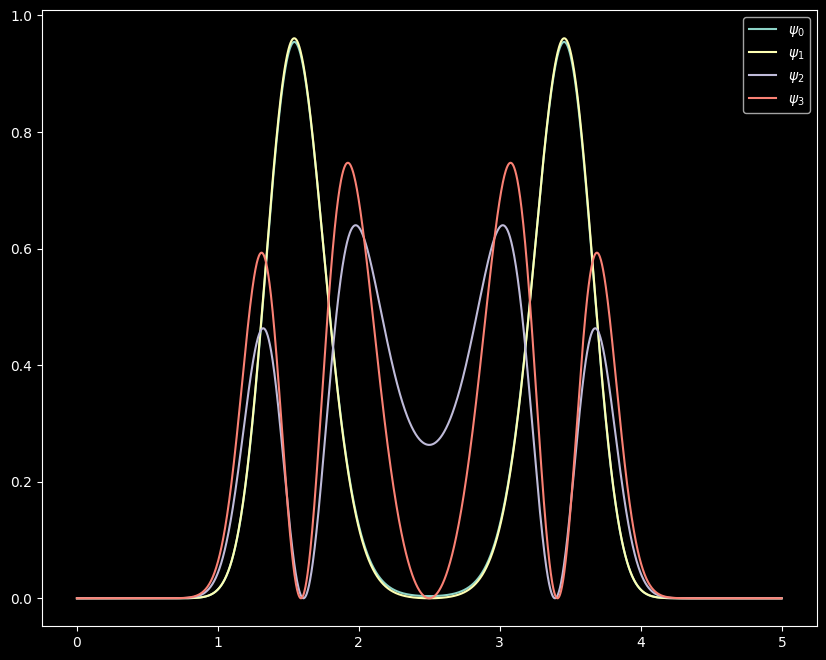

In [11]:
# Plot
plt.style.use("dark_background")
plt.figure(figsize=(10,8))

for n in range(0,4):

    plt.plot(x[1:-1], psi[:,n]**2, label = "$\psi_{}$".format(n))
    plt.legend()

<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
C:\Users\ahila\AppData\Local\Temp\ipykernel_40352\1108676245.py:11: SyntaxWarning: invalid escape sequence '\p'
  label=f"$\psi_{n}^2$  (E={E[n]:.2f})",


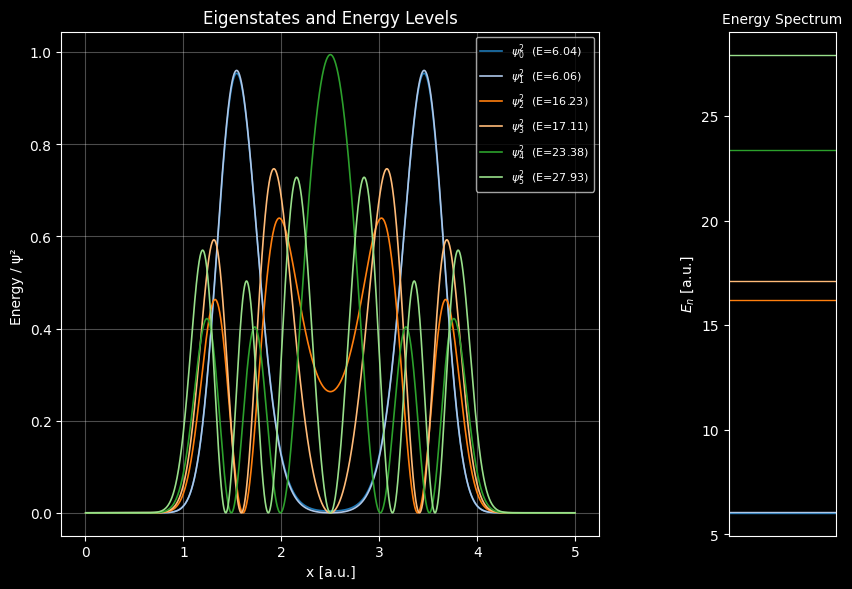

In [12]:
plt.style.use("dark_background")


fig, (ax_main, ax_bar) = plt.subplots(
    1, 2, figsize=(10, 8), gridspec_kw={'width_ratios': [5, 1]})
plt.subplots_adjust(bottom=0.25, wspace=0.4)

for n in range(6):
    ax_main.plot(
        x[1:-1], psi[:, n]**2 , 
        label=f"$\psi_{n}^2$  (E={E[n]:.2f})",
        lw=1.2, # Bigger discrete palette (20 colors)
c = plt.colormaps['tab20'].colors[n % 20] # For unique Matching colour
)

#ax_main.set_xlim(x[1], x[-2])
ax_main.set_xlabel("x [a.u.]")
ax_main.set_ylabel("Energy / ψ² ")
ax_main.set_title("Eigenstates and Energy Levels")
ax_main.legend(loc="upper right", fontsize=8)
ax_main.grid(alpha=0.3)


ax_bar.set_title("Energy Spectrum", fontsize=10)
#ax_bar.set_xlim(0, 1)
#ax_bar.set_ylim(0, np.max(E)*1.1)
ax_bar.set_xticks([])
ax_bar.set_ylabel(r"$E_n$ [a.u.]")

for n in range(6):
    ax_bar.axhline(E[n], c = plt.colormaps['tab20'].colors[n % 20]
, lw=1)
plt.show()


In [13]:
bool(0)

False

<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:28: SyntaxWarning: invalid escape sequence '\p'
C:\Users\ahila\AppData\Local\Temp\ipykernel_40352\2687922550.py:28: SyntaxWarning: invalid escape sequence '\p'
  label=f"$\psi_{n}$  (E={E[n]:.2f})",


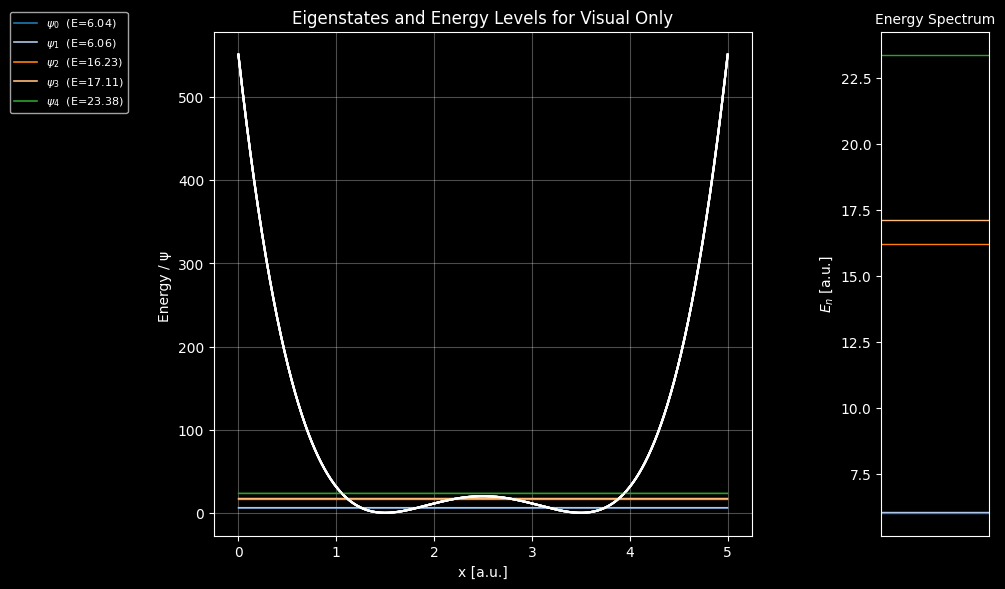

In [14]:
# Inaccurate Plot for intution (Like the Textbook)

plt.style.use("dark_background")


# The texbook makes a few simplifications, firstly, all of the are vertically shifted with an exaguaration


nos = 5


fig, (ax_main, ax_bar) = plt.subplots(
    1, 2, figsize=(10, 8), gridspec_kw={'width_ratios': [5, 1]})
plt.subplots_adjust(bottom=0.25, wspace=0.4)

#scale = max(psi[:,0])/max(V)
scale = (E[1]-E[0])*0.4

for n in range(nos):
    
    psi_nth = psi[:, n]
    psi_nth = psi_nth / np.max(np.abs(psi_nth))
    vertical_shifted = psi_nth*scale+E[n] ##????
    
    
    ax_main.plot(
        x[1:-1], vertical_shifted , 
        label=f"$\psi_{n}$  (E={E[n]:.2f})",
        lw=1.2, # Bigger discrete palette (20 colors)
c = plt.colormaps['tab20'].colors[n % 20] # For unique Matching colour
)
    ax_main.plot(x,V,color='white')

# Plot the Walls
for i in range(len(walls_array)):        
        try: 
            ax_main.axvline(walls_array[i], color='white', lw=2)
        except NameError:
            None

#ax_main.set_xlim(x[1], x[-2])
ax_main.set_xlabel("x [a.u.]")
ax_main.set_ylabel("Energy / ψ ")
#ax_main.set_ylim(0, np.max(psi_nth)*40)

#ax_main.set_ylim(0,np.max(vertical_shifted)+2)

ax_main.set_title("Eigenstates and Energy Levels for Visual Only")
ax_main.legend(bbox_to_anchor=(-0.15, 1.05), fontsize=8)
ax_main.grid(alpha=0.3)


ax_bar.set_title("Energy Spectrum", fontsize=10)
#ax_bar.set_xlim(0, 1)
ax_bar.set_xticks([])
ax_bar.set_ylabel(r"$E_n$ [a.u.]")

for n in range(nos):
    ax_bar.axhline(E[n], c = plt.colormaps['tab20'].colors[n % 20]
, lw=1)
plt.show()
